In [1]:
import mlflow

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [59]:
import mlflow.artifacts
import mlflow.experiments
import mlflow.artifacts
import pickle
runs = mlflow.search_runs(experiment_ids=["655267190825023398"])
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import pandas as pd

### Trimming effect

In [116]:
results = []
for index, row in runs.iterrows():
    trimming_type = row["tags.data_preparation"]
    chr = row["tags.mlflow.runName"].replace("_cpg_counts_selected", "").replace("chromosome_", "")
    if trimming_type is not None:
        tmp_path = mlflow.artifacts.download_artifacts (row["artifact_uri"] +"/predictions/rest_predictions.pkl")
        f = open(tmp_path,'rb')
        predictions = pickle.load(f)
        f.close()
        mcc = matthews_corrcoef(predictions["true_label"],  predictions["predicted_probability"]>0.5)
        rocauc = roc_auc_score(predictions["true_label"],  predictions["predicted_probability"])
        results.append((chr, trimming_type, rocauc, mcc))

# Manual append of chr1 naive_cut result, that had pretty much the same scores but I didn't save the run, so...
results.append(("chr1","naive_cut", 0.984277, 0.814831))

In [118]:
results = pd.DataFrame(results, columns=["chromosome", "trimming_type", "roc_auc", "mcc"])
results["DMRs"] = "All"

### DMR filtering effect

In [75]:
runs_dmr_filtered = mlflow.search_runs(experiment_ids=["564481821195479800"])
runs_dmr_filtered = runs_dmr_filtered.loc[runs_dmr_filtered["tags.architecture"]=="dismir_minigru"]
results_dmr_filtered = []
for index, row in runs_dmr_filtered.iterrows():
    chr = row["tags.mlflow.runName"].replace("_cpg_counts_selected", "").replace("chromosome_", "")
    trimming_type = "naive_cut"
    tmp_path = mlflow.artifacts.download_artifacts (row["artifact_uri"] +"/predictions/test_whole_reads_predictions.pkl")
    f = open(tmp_path,'rb')
    predictions = pickle.load(f)
    f.close()
    mcc = matthews_corrcoef(predictions["true_label"],  predictions["predicted_probability"]>0.5)
    rocauc = roc_auc_score(predictions["true_label"],  predictions["predicted_probability"])
    results_dmr_filtered.append((chr, trimming_type, rocauc, mcc))

x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [81]:
results_dmr_filtered = pd.DataFrame(results_dmr_filtered, columns=["chromosome", "trimming_type", "roc_auc", "mcc"])

In [82]:
results_dmr_filtered["DMRs"] = "Top 3000"

In [120]:
results_dmr = pd.concat([results.loc[results["trimming_type"]=="naive_cut"],results_dmr_filtered])

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Create the paired comparison plot
def create_paired_comparison_plot(df, save_path=None, figsize=(10, 8)):
    """
    Create a paired comparison plot for two trimming strategies.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: chromosome, trimming_type, roc_auc, mcc
    save_path : str, optional
        Path to save the figure
    figsize : tuple
        Figure size (width, height)
    """
    
    # Pivot the data to get paired values
    pivot_mcc = df.pivot(index='chromosome', columns='trimming_type', values='mcc')
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define colors
    color_above = '#2E86AB'  # Blue for points where max_cpg is better
    color_below = '#A23B72'  # Pink for points where first_1000 is better
    color_equal = '#F18F01'  # Orange for approximately equal
    
    # Plot diagonal reference line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Equal performance')
    
    # Plot points
    for idx, row in pivot_mcc.iterrows():
        x = row['naive_cut']
        y = row['cpg_counts_cut']
        
        # Determine color based on which strategy is better
        if abs(x - y) < 0.02:  # Consider approximately equal
            color = color_equal
            marker = 's'  # Square for equal
        elif y > x:
            color = color_above
            marker = '^'  # Triangle up for max_cpg better
        else:
            color = color_below
            marker = 'v'  # Triangle down for first_1000 better
        
        # Plot point
        ax.scatter(x, y, c=color, s=100, alpha=0.7, edgecolors='black', 
                  linewidth=0.5, marker=marker)
        
        # Label chromosomes with significant differences
        if abs(x - y) > 0.2:  # Threshold for labeling
            ax.annotate(idx, (x, y), xytext=(5, 5), textcoords='offset points',
                       fontsize=9, alpha=0.8)
    
    # Add shaded regions
    ax.fill_between([0, 1], [0, 1], [1, 1], alpha=0.1, color=color_above)
    ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.1, color=color_below)
    
    # Customize plot
    ax.set_xlabel('MCC - Naive Trimming', fontsize=12)
    ax.set_ylabel('MCC - Heuristic Cut \n (Maximal CpG Concentration)', fontsize=12)
    # ax.set_title('Paired Comparison of Trimming Strategies\nby Chromosome', 
    #             fontsize=14, fontweight='bold')
    
    # Set equal aspect ratio and limits
    ax.set_aspect('equal')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle=':')
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='^', color='w', markerfacecolor=color_above, 
               markersize=10, label='Maximal CpG better', markeredgecolor='black'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor=color_below, 
               markersize=10, label='First 1000 better', markeredgecolor='black'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor=color_equal, 
               markersize=10, label='Similar performance', markeredgecolor='black'),
        Line2D([0], [0], color='k', linestyle='--', label='Equal performance line')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, 
              fancybox=True, shadow=True)
    
    # Add summary statistics
    n_max_cpg_better = sum(pivot_mcc['cpg_counts_cut'] > 
                          pivot_mcc['naive_cut'] + 0.02)
    n_first_1000_better = sum(pivot_mcc['naive_cut'] > 
                             pivot_mcc['cpg_counts_cut'] + 0.02)
    n_similar = len(pivot_mcc) - n_max_cpg_better - n_first_1000_better
    
    # Add text box with summary
    textstr = f'Summary:\n{n_max_cpg_better} chromosomes: Heuristic cut better\n'
    textstr += f'{n_first_1000_better} chromosomes: Naive trimming better\n'
    textstr += f'{n_similar} chromosomes: Similar performance'
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

In [123]:
def create_dmr_comparison_plot(df, save_path=None, figsize=(10, 8)):
    """
    Create a paired comparison plot for two DMR filtering strategies.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: chromosome, trimming_type, roc_auc, mcc, DMRs
    save_path : str, optional
        Path to save the figure
    figsize : tuple
        Figure size (width, height)
    """
    
    # Handle NaN values in roc_auc by using MCC for missing values
    df = df.copy()
    
    # Pivot the data to get paired values
    pivot_mcc = df.pivot(index='chromosome', columns='DMRs', values='mcc')
    pivot_roc = df.pivot(index='chromosome', columns='DMRs', values='roc_auc')
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define colors
    color_top3000_better = '#2E86AB'  # Blue for points where Top 3000 is better
    color_all_better = '#A23B72'      # Pink for points where All DMRs is better
    color_equal = '#F18F01'           # Orange for approximately equal
    
    # Plot diagonal reference line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Equal performance')
    
    # Track chromosomes with significant improvements
    major_improvements = []
    
    # Plot points
    for idx, row in pivot_mcc.iterrows():
        x = row['All']
        y = row['Top 3000']
        
        # Skip if either value is NaN
        if pd.isna(x) or pd.isna(y):
            continue
        
        # Calculate improvement
        improvement = y - x
        
        # Determine color based on which strategy is better
        if abs(improvement) < 0.02:  # Consider approximately equal
            color = color_equal
            marker = 's'  # Square for equal
        elif improvement > 0:
            color = color_top3000_better
            marker = '^'  # Triangle up for Top 3000 better
            if improvement > 0.2:  # Track major improvements
                major_improvements.append((idx, x, y, improvement))
        else:
            color = color_all_better
            marker = 'v'  # Triangle down for All better
        
        # Plot point
        ax.scatter(x, y, c=color, s=100, alpha=0.7, edgecolors='black', 
                  linewidth=0.5, marker=marker)
        
        # Label chromosomes with significant differences
        if abs(improvement) > 0.12:  # Threshold for labeling
            ax.annotate(idx, (x, y), xytext=(5, 5), textcoords='offset points',
                       fontsize=9, alpha=0.8)
    
    # Add shaded regions
    ax.fill_between([0, 1], [0, 1], [1, 1], alpha=0.1, color=color_top3000_better)
    ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.1, color=color_all_better)
    
    # Customize plot
    ax.set_xlabel('MCC - All DMRs', fontsize=12)
    ax.set_ylabel('MCC - Top 3000 DMRs', fontsize=12)
    # ax.set_title('Paired Comparison of DMR Filtering Strategies\nby Chromosome', 
    #             fontsize=14, fontweight='bold')
    
    # Set equal aspect ratio and limits
    ax.set_aspect('equal')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle=':')
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='^', color='w', markerfacecolor=color_top3000_better, 
               markersize=10, label='Top 3000 better', markeredgecolor='black'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor=color_all_better, 
               markersize=10, label='All DMRs better', markeredgecolor='black'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor=color_equal, 
               markersize=10, label='Similar performance', markeredgecolor='black'),
        Line2D([0], [0], color='k', linestyle='--', label='Equal performance line')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, 
              fancybox=True, shadow=True)
    
    # Add summary statistics
    valid_pairs = pivot_mcc.dropna()
    n_top3000_better = sum(valid_pairs['Top 3000'] > valid_pairs['All'] + 0.02)
    n_all_better = sum(valid_pairs['All'] > valid_pairs['Top 3000'] + 0.02)
    n_similar = len(valid_pairs) - n_top3000_better - n_all_better
    
    # Calculate average improvement
    avg_improvement = (valid_pairs['Top 3000'] - valid_pairs['All']).mean()
    
    # Add text box with summary
    textstr = f'Summary:\n{n_top3000_better} chromosomes: Top 3000 better\n'
    textstr += f'{n_all_better} chromosomes: All DMRs better\n'
    textstr += f'{n_similar} chromosomes: Similar performance\n'
    textstr += f'Avg improvement: {avg_improvement:.3f}'
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    # Highlight major improvements
    if major_improvements:
        improvement_text = "Major improvements (>0.2):\n"
        for chr_name, all_val, top3000_val, imp in sorted(major_improvements, 
                                                          key=lambda x: x[3], 
                                                          reverse=True)[:5]:
            improvement_text += f"{chr_name}: {all_val:.3f} → {top3000_val:.3f} (+{imp:.3f})\n"
        
        props2 = dict(boxstyle='round', facecolor='lightblue', alpha=0.8, edgecolor='blue')
        ax.text(0.98, 0.22, improvement_text.rstrip(), transform=ax.transAxes, 
                fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                bbox=props2)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

(<Figure size 700x1000 with 1 Axes>,
 <Axes: xlabel='MCC - Naive Trimming', ylabel='MCC - Heuristic Cut \n (Maximal CpG Concentration)'>)

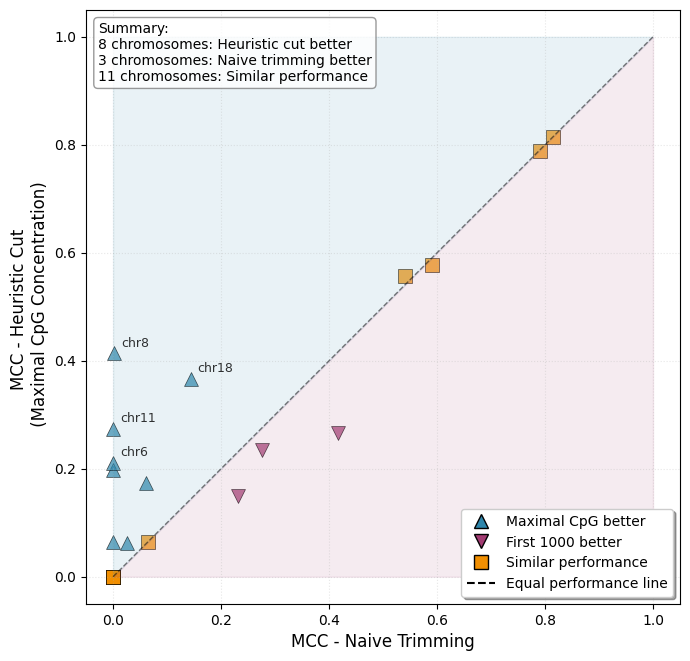

In [119]:
create_paired_comparison_plot(results,figsize=(7,10))

(<Figure size 700x1000 with 1 Axes>,
 <Axes: xlabel='MCC - All DMRs', ylabel='MCC - Top 3000 DMRs'>)

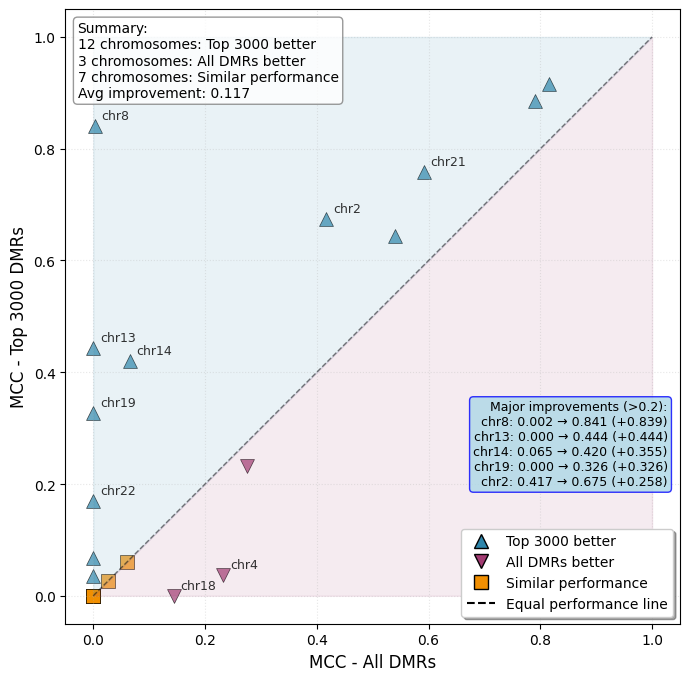

In [124]:
create_dmr_comparison_plot(results_dmr, figsize=(7,10))